# Portfolio Analysis Project Assignment


In [79]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [80]:
selected_seven = ["T", "ORCL", "DAL", "BBY", "DIS","CAT", "WRB"]
market_etfs = ["SPY", "IWM", "DIA"]
all_tickers = selected_seven + market_etfs

I chose the following diverse set of stocks:
| Stock | Company Name | Industry |
| :--- | :--- | :--- |
| **T** | AT&T Inc. | Diversified Telecommunication Services |
| **ORCL** | Oracle Corporation | Software |
| **DAL** | Delta Air Lines, Inc. | Passenger Airlines |
| **BBY** | Best Buy Co., Inc. | Specialty Retail |
| **DIS** | The Walt Disney Company | Entertainment |
| **CAT** | Caterpillar Inc. | Machinery |
| **WRB** | W. R. Berkley Corporation | Insurance |

In [81]:
as_of_date = "2026-03-24"
start_date = pd.to_datetime(as_of_date) - pd.DateOffset(years=10)
download_end = pd.to_datetime(as_of_date) + pd.Timedelta(days=1)

downloaded = yf.download(all_tickers, start=start_date.strftime("%Y-%m-%d"),
                         end = download_end.strftime("%Y-%m-%d"),
                         auto_adjust=True,
                         progress=False)

prices = downloaded["Close"].copy()

missing_tickers = sorted(set(all_tickers) - set(prices.columns))

if missing_tickers:
    raise ValueError(f"Missing downloaded tickers: {missing_tickers}")


stocks = prices.reindex(columns=selected_seven)
market_index = prices.reindex(columns=market_etfs)

assert stocks.columns.tolist() == selected_seven
assert market_index.columns.tolist() == market_etfs

stocks.head()

Ticker,T,ORCL,DAL,BBY,DIS,CAT,WRB
Date,,,,,,,
2016-03-24,14.360081,35.149883,42.204281,21.907785,89.611259,59.414108,12.713227
2016-03-28,14.430256,34.849606,42.521873,21.970802,90.413170,59.437771,12.859603
2016-03-29,14.570603,34.918240,43.342323,22.194849,90.477692,59.982243,13.017779
2016-03-30,14.541053,35.149883,43.518757,22.103827,91.168999,60.376827,13.256224
2016-03-31,14.467190,35.098392,42.945332,22.712961,91.537689,60.400520,13.268029


- `stocks` - daily close-price DataFrame for the 7 selected tickers.
- `market_index` - daily close-price DataFrame for `SPY`, `IWM`, and `DIA.`

In [82]:
market_index.head()

Ticker,SPY,IWM,DIA
Date,,,
2016-03-24,172.568634,94.282516,143.406998
2016-03-28,172.670563,94.396851,143.554474
2016-03-29,174.267761,97.017761,144.333252
2016-03-30,175.032425,97.026566,145.005493
2016-03-31,174.607651,97.299210,144.800613


## Part 1 - Comparison of Stocks against the market ETFs

We create a new DataFrame `stock_vs_market` which will store how each stock compare against market ETFs.

In [83]:
stock_returns = stocks.pct_change().dropna()
market_returns = market_index.pct_change().dropna()

# dataframe `stock_vs_market` to compare individual stock to market ETFs (SPY, IWM, DIA)

stock_vs_market = pd.DataFrame(index=selected_seven)

stock_vs_market = pd.DataFrame({

    # 1a. portfolio weight: equal-weighted portfolio, so each stock has the same weight, which is `1/len(selected_seven)`.
    "portfolio_weight": [1/len(selected_seven)] * len(selected_seven),
    
    # 1b. annualized volatility: calculated using the standard deviation of daily returns over the trailing 
    # 3 months (63 trading days), and then annualized by multiplying by the square root of 252 (the number of trading days in a year).
    # using square-root-of-time rule to annualize volatility: `252**0.5` is the same as `sqrt(252)`, where 252 is the number of trading days 
    # in a year.
    # Source: NumPy documentation — np.sqrt() returns the square root.
    # Finance convention: annualized volatility = daily return standard deviation * sqrt(252 trading days).
    # https://numpy.org/doc/2.1/reference/generated/numpy.sqrt.html 
    "annualized_volatility": stock_returns.tail(63).std() * (252**0.5) # trailing 3 months volatility

})

stock_vs_market

,portfolio_weight,annualized_volatility
Ticker,,
T,0.142857,0.254497
ORCL,0.142857,0.512857
DAL,0.142857,0.433544
BBY,0.142857,0.353702
DIS,0.142857,0.281813
CAT,0.142857,0.354022
WRB,0.142857,0.203947


In [84]:
stock_vs_market.sort_values("annualized_volatility", ascending=False)

,portfolio_weight,annualized_volatility
Ticker,,
ORCL,0.142857,0.512857
DAL,0.142857,0.433544
CAT,0.142857,0.354022
BBY,0.142857,0.353702
DIS,0.142857,0.281813
T,0.142857,0.254497
WRB,0.142857,0.203947


Equal weight was assigned to each of the seven stocks. `T` and `WRB` are the least volatile stocks as per the annualized trailing 3-months data with volatilities of `0.26` and `0.20` respectively. `ORCL` tops the list with a volatility of `0.51`.

In [85]:


# beta calculation: trailing 12 months (approx. 252 trading days)
# Align dates before computing cov/var.
trailing_days = 252
# stocks_12mo = stocks.tail(trailing_days)
# market_12m = market_index.tail(trailing_days)


stock_ret_12m = stock_returns.tail(trailing_days)
market_ret_12m = market_returns.tail(trailing_days)

# 1d, e, f. beta calculation for each stock against each market index (SPY, IWM, DIA)
for etf in market_etfs:
    aligned = pd.concat(
        [stock_ret_12m, market_ret_12m[etf].rename(etf)],
        axis=1
    ).dropna()

    stock_vs_market[f"beta_{etf}"] = aligned[selected_seven].apply(
        lambda stock: stock.cov(aligned[etf]) / aligned[etf].var()
    )

stock_vs_market

,portfolio_weight,annualized_volatility,beta_SPY,beta_IWM,beta_DIA
Ticker,,,,,
T,0.142857,0.254497,0.061019,-0.014346,0.195160
ORCL,0.142857,0.512857,1.361176,0.916003,1.070455
DAL,0.142857,0.433544,1.905955,1.660378,2.160187
BBY,0.142857,0.353702,1.382113,1.224079,1.603010
DIS,0.142857,0.281813,1.069825,0.829381,1.223684
CAT,0.142857,0.354022,1.212835,1.078037,1.384068
WRB,0.142857,0.203947,0.200850,0.149981,0.375810


`T` is the most defensive holding based on beta, with beta near zero against `SPY` and `IWM` and only `0.20` against `DIA`. `WRB` is also defensive, with beta below` 0.40` against all three ETFs. By contrast, `DAL` is the most aggressive holding, with beta above `1.65` against all benchmarks and above `2.0` against DIA.

In [86]:
# average weekly drawdown calculation

# Source: pandas documentation — DataFrame.rolling() provides rolling window calculations.
# Used here to calculate rolling 52-week highs and lows for the assignment's drawdown formula.
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html
weekly_prices = stocks.resample('W').last().dropna(how="all")
high_52 = weekly_prices.rolling(window=52).max()
low_52 = weekly_prices.rolling(window=52).min()
weekly_drawdown = (low_52 - high_52) / high_52

stock_vs_market["average_weekly_drawdown"] = weekly_drawdown.mean()
stock_vs_market["maximum_weekly_drawdown"] = weekly_drawdown.min()
stock_vs_market


,portfolio_weight,annualized_volatility,beta_SPY,beta_IWM,beta_DIA,average_weekly_drawdown,maximum_weekly_drawdown
Ticker,,,,,,,
T,0.142857,0.254497,0.061019,-0.014346,0.195160,-0.250019,-0.444064
ORCL,0.142857,0.512857,1.361176,0.916003,1.070455,-0.322227,-0.586795
DAL,0.142857,0.433544,1.905955,1.660378,2.160187,-0.382340,-0.688496
BBY,0.142857,0.353702,1.382113,1.224079,1.603010,-0.372343,-0.585255
DIS,0.142857,0.281813,1.069825,0.829381,1.223684,-0.313858,-0.563907
CAT,0.142857,0.354022,1.212835,1.078037,1.384068,-0.353456,-0.632950
WRB,0.142857,0.203947,0.200850,0.149981,0.375810,-0.277684,-0.418328


In [87]:
# total return - trailing 10-years
total_return = (stocks.iloc[-1] / stocks.iloc[0]) - 1
stock_vs_market["total_return"] = total_return
stock_vs_market

,portfolio_weight,annualized_volatility,beta_SPY,beta_IWM,beta_DIA,average_weekly_drawdown,maximum_weekly_drawdown,total_return
Ticker,,,,,,,,
T,0.142857,0.254497,0.061019,-0.014346,0.195160,-0.250019,-0.444064,0.989611
ORCL,0.142857,0.512857,1.361176,0.916003,1.070455,-0.322227,-0.586795,3.170087
DAL,0.142857,0.433544,1.905955,1.660378,2.160187,-0.382340,-0.688496,0.575045
BBY,0.142857,0.353702,1.382113,1.224079,1.603010,-0.372343,-0.585255,1.816807
DIS,0.142857,0.281813,1.069825,0.829381,1.223684,-0.313858,-0.563907,0.075646
CAT,0.142857,0.354022,1.212835,1.078037,1.384068,-0.353456,-0.632950,11.038694
WRB,0.142857,0.203947,0.200850,0.149981,0.375810,-0.277684,-0.418328,4.115145


In [88]:
# annualized total return - trailing 10-years
years = (stocks.index[-1] - stocks.index[0]).days / 365.25
stock_vs_market["annualized_return"] = (
    (stocks.iloc[-1] / stocks.iloc[0]) ** (1 / years) - 1
)
stock_vs_market

,portfolio_weight,annualized_volatility,beta_SPY,beta_IWM,beta_DIA,average_weekly_drawdown,maximum_weekly_drawdown,total_return,annualized_return
Ticker,,,,,,,,,
T,0.142857,0.254497,0.061019,-0.014346,0.195160,-0.250019,-0.444064,0.989611,0.071226
ORCL,0.142857,0.512857,1.361176,0.916003,1.070455,-0.322227,-0.586795,3.170087,0.153514
DAL,0.142857,0.433544,1.905955,1.660378,2.160187,-0.382340,-0.688496,0.575045,0.046483
BBY,0.142857,0.353702,1.382113,1.224079,1.603010,-0.372343,-0.585255,1.816807,0.109128
DIS,0.142857,0.281813,1.069825,0.829381,1.223684,-0.313858,-0.563907,0.075646,0.007320
CAT,0.142857,0.354022,1.212835,1.078037,1.384068,-0.353456,-0.632950,11.038694,0.282545
WRB,0.142857,0.203947,0.200850,0.149981,0.375810,-0.277684,-0.418328,4.115145,0.177323


## 2. comparing the portfolio against the 3 market indices

In [90]:
# Source: pandas documentation — DataFrame.pct_change() computes fractional change from the previous row.
# Used here to convert daily prices into daily returns.
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pct_change.html

weights = np.array([1/len(stocks.columns)] * len(stocks.columns))

portfolio_returns = stock_returns.dot(weights)
# Rename the series to "Portfolio" for clarity
portfolio_returns = portfolio_returns.rename("Portfolio")
# current risk free rate
risk_free_rate = 0.03

def sharpe_ratio(returns, risk_free_rate=0.03):
    return ((returns.mean() - risk_free_rate / 252) / returns.std()) * np.sqrt(252)


portfolio_rows = []

for etf in market_etfs:
    combined = pd.concat(
        [portfolio_returns, market_returns[etf].rename(etf)],
        axis=1
    ).dropna()

    active_return = combined["Portfolio"] - combined[etf]

    portfolio_rows.append({
        "ticker": etf,
        "correlation": combined["Portfolio"].corr(combined[etf]),
        "covariance": combined["Portfolio"].cov(combined[etf]),
        "tracking_error": active_return.std() * np.sqrt(252),
        "portfolio_sharpe_ratio": sharpe_ratio(combined["Portfolio"], risk_free_rate),
        "etf_sharpe_ratio": sharpe_ratio(combined[etf], risk_free_rate),
        "sharpe_difference": (
            sharpe_ratio(combined["Portfolio"], risk_free_rate)
            - sharpe_ratio(combined[etf], risk_free_rate)
        ),
        "annualized_volatility_spread": (
            combined["Portfolio"].std() * np.sqrt(252)
            - combined[etf].std() * np.sqrt(252)
        )
    })

portfolio_vs_market = pd.DataFrame(portfolio_rows)
portfolio_vs_market

,ticker,correlation,covariance,tracking_error,portfolio_sharpe_ratio,etf_sharpe_ratio,sharpe_difference,annualized_volatility_spread
0,SPY,0.840178,0.000126,0.114247,0.632223,0.668434,-0.036211,0.031795
1,IWM,0.824743,0.000158,0.131582,0.632223,0.408559,0.223664,-0.018982
2,DIA,0.871505,0.000127,0.103667,0.632223,0.585883,0.046340,0.035850


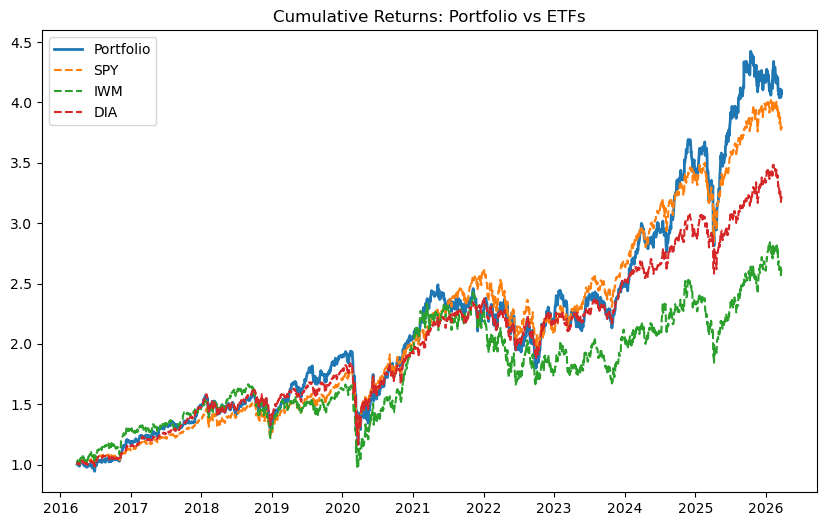

In [91]:
# portfolio vs ETFS - how portfolio performs versus SPY, IWM, and DIA
portfolio_cum = (1 + portfolio_returns).cumprod()

market_cum = (1 + market_index.pct_change()).cumprod()

plt.figure(figsize=(10,6))
plt.plot(portfolio_cum, label="Portfolio", linewidth=2)

for col in market_cum.columns:
    plt.plot(market_cum[col], label=col, linestyle="--")

plt.title("Cumulative Returns: Portfolio vs ETFs")
plt.legend()
plt.show()

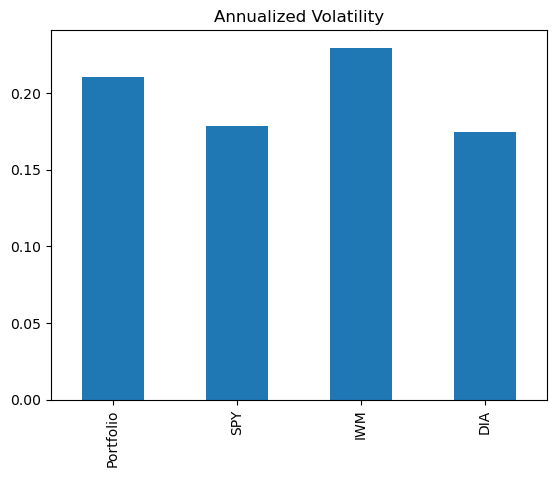

In [92]:
# portfolio risk vs ETFs - is the portfolio more or less volatile than SPY, IWM, and DIA?

vol_data = {
    "Portfolio": portfolio_returns.std() * np.sqrt(252),
}

for col in market_index.columns:
    vol_data[col] = market_index[col].pct_change().std() * np.sqrt(252)

pd.Series(vol_data).plot(kind="bar", title="Annualized Volatility")
plt.show()

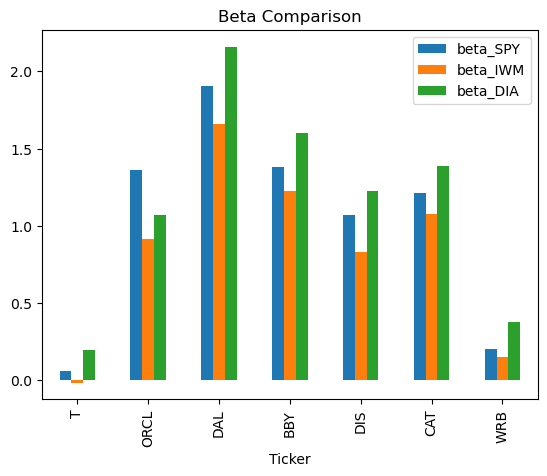

In [74]:
# beta comparision chart - aggressive vs defensive
stock_vs_market[["beta_SPY", "beta_IWM", "beta_DIA"]].plot(kind="bar")
plt.title("Beta Comparison")
plt.show()

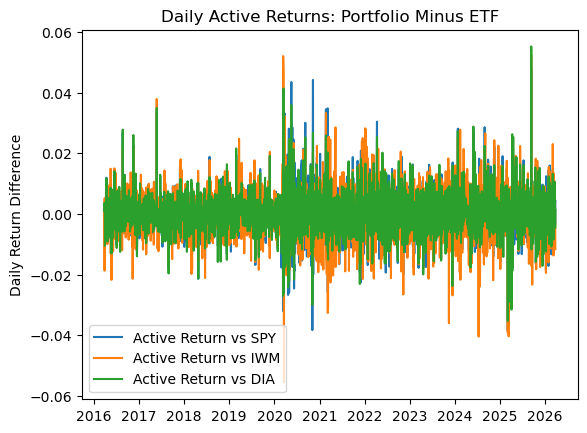

In [77]:
# Daily active-return visualization
for etf in market_etfs:
    active_return = portfolio_returns - market_returns[etf]
    plt.plot(active_return, label=f"Active Return vs {etf}")

plt.legend()
plt.title("Daily Active Returns: Portfolio Minus ETF")
plt.ylabel("Daily Return Difference")
plt.show()

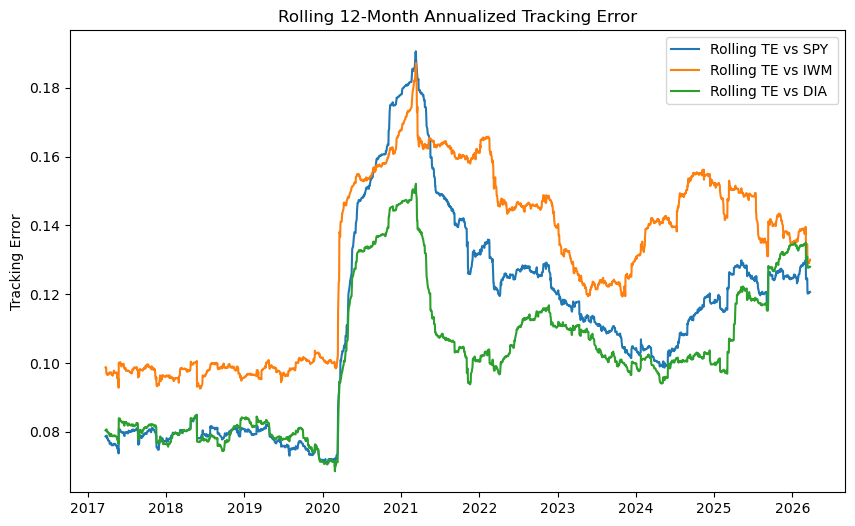

In [78]:
plt.figure(figsize=(10, 6))

for etf in market_etfs:
    active_return = portfolio_returns - market_returns[etf]
    rolling_tracking_error = active_return.rolling(252).std() * np.sqrt(252)
    plt.plot(rolling_tracking_error, label=f"Rolling TE vs {etf}")

plt.legend()
plt.title("Rolling 12-Month Annualized Tracking Error")
plt.ylabel("Tracking Error")
plt.show()

## 3. Correlation Matrix

In [71]:
# convert to dataframe for easier calculations

# Source: pandas documentation — DataFrame.corr() computes the correlation matrix.
# Source: Matplotlib documentation/examples — imshow() can display matrix-style data as an image/heatmap.
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html

portfolio_returns_df = portfolio_returns.to_frame()

# part 3 -  Create a correlation matrix showing the correlations between the equal-weighted portfolio created from 
# your 7 assets, the 3 ETFs, and your 7 individual stocks

# Combine the portfolio, ETFs, and individual stocks into a single DataFrame
combined_data = pd.concat(
    [portfolio_returns_df, 
     market_returns.reindex(columns=market_etfs), 
     stock_returns.reindex(columns=selected_seven)
     ],
    axis=1
).dropna()

# Calculate the correlation matrix
correlation_matrix = combined_data.corr()

correlation_matrix

,Portfolio,SPY,IWM,DIA,T,ORCL,DAL,BBY,DIS,CAT,WRB
Portfolio,1.000000,0.840178,0.824743,0.871505,0.552077,0.579347,0.752646,0.677244,0.716813,0.719947,0.625156
SPY,0.840178,1.000000,0.864639,0.945909,0.420180,0.548193,0.580177,0.543592,0.628033,0.638686,0.539141
IWM,0.824743,0.864639,1.000000,0.848756,0.380489,0.430925,0.639511,0.559839,0.600133,0.665950,0.517723
DIA,0.871505,0.945909,0.848756,1.000000,0.484920,0.489664,0.606971,0.541094,0.640987,0.692348,0.622775
T,0.552077,0.420180,0.380489,0.484920,1.000000,0.181752,0.286393,0.269302,0.350073,0.307178,0.417678
ORCL,0.579347,0.548193,0.430925,0.489664,0.181752,1.000000,0.271997,0.279578,0.299526,0.351656,0.251124
DAL,0.752646,0.580177,0.639511,0.606971,0.286393,0.271997,1.000000,0.395659,0.510665,0.468491,0.379770
BBY,0.677244,0.543592,0.559839,0.541094,0.269302,0.279578,0.395659,1.000000,0.390241,0.387330,0.269994
DIS,0.716813,0.628033,0.600133,0.640987,0.350073,0.299526,0.510665,0.390241,1.000000,0.433527,0.383098
CAT,0.719947,0.638686,0.665950,0.692348,0.307178,0.351656,0.468491,0.387330,0.433527,1.000000,0.405864


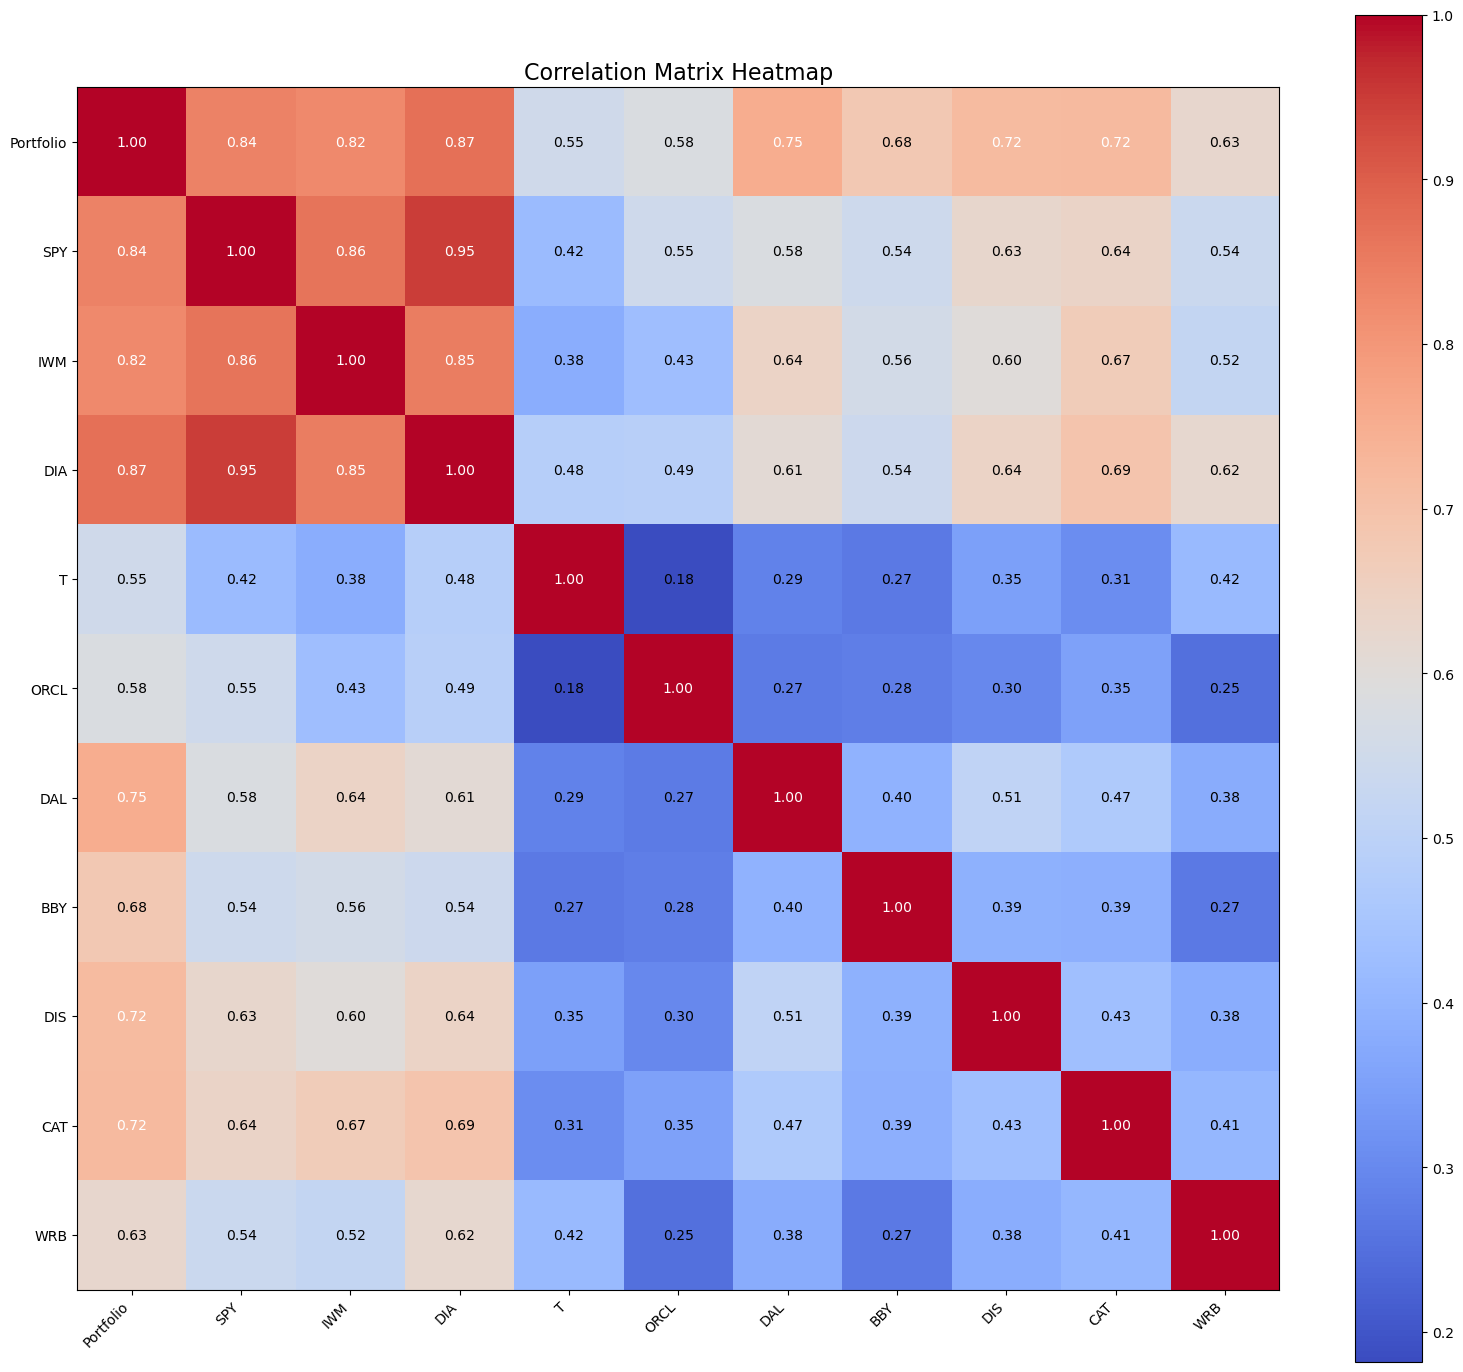

In [72]:
# correlation matrix heatmap

# Use your correlation matrix
corr = correlation_matrix.values
labels = correlation_matrix.columns

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(corr, cmap="coolwarm")

# Show all ticks
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

# Loop over data dimensions and create text annotations manually
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        color = "white" if abs(corr[i, j]) > 0.7 else "black"
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", color=color)

# Add colorbar
fig.colorbar(im)
plt.title("Correlation Matrix Heatmap", fontsize=16)
plt.tight_layout()
plt.show()